100%|██████████| 9.91M/9.91M [00:00<00:00, 39.1MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.13MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 10.1MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.24MB/s]


--- BẮT ĐẦU HUẤN LUYỆN 10 EPOCH ---
Epoch [1/10] -> Train Acc: 94.30% | Test Acc: 97.95%
Epoch [2/10] -> Train Acc: 98.06% | Test Acc: 98.15%
Epoch [3/10] -> Train Acc: 98.48% | Test Acc: 98.71%
Epoch [4/10] -> Train Acc: 98.68% | Test Acc: 98.49%
Epoch [5/10] -> Train Acc: 98.83% | Test Acc: 98.60%
Epoch [6/10] -> Train Acc: 99.05% | Test Acc: 98.98%
Epoch [7/10] -> Train Acc: 99.12% | Test Acc: 98.88%
Epoch [8/10] -> Train Acc: 99.19% | Test Acc: 98.83%
Epoch [9/10] -> Train Acc: 99.28% | Test Acc: 98.73%
Epoch [10/10] -> Train Acc: 99.30% | Test Acc: 98.91%


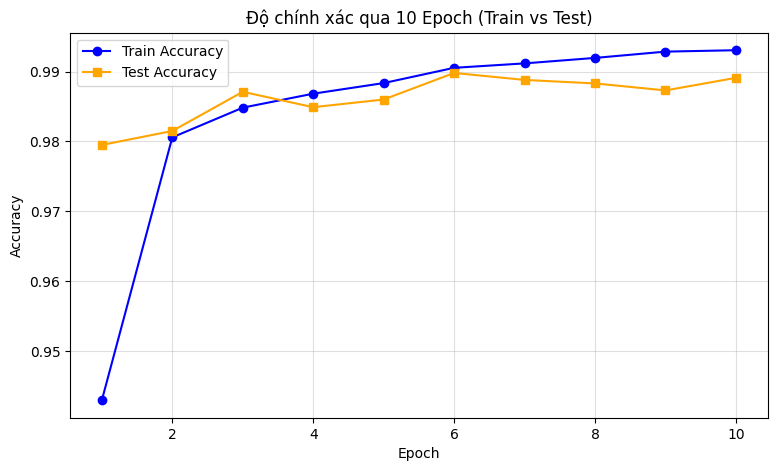

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Cấu hình thiết bị
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

# 1. Chuẩn bị dữ liệu MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1000, shuffle=False)

# 2. Định nghĩa lại cấu hình mạng CNN gốc
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.fc1(x)

# Khởi tạo mô hình
model = MNIST_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# Lịch sử đo lường
train_acc_history = []
test_acc_history = []

# 3. Vòng lặp huấn luyện trong 10 Epoch
num_epochs = 10
print("--- BẮT ĐẦU HUẤN LUYỆN 10 EPOCH ---")

for epoch in range(num_epochs):
    model.train()
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        correct_train += (outputs.argmax(1) == labels).sum().item()
        total_train += images.size(0)

    # Đánh giá trên tập Test cuối mỗi epoch
    model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            correct_test += (outputs.argmax(1) == labels).sum().item()
            total_test += images.size(0)

    train_acc = correct_train / total_train
    test_acc = correct_test / total_test
    train_acc_history.append(train_acc)
    test_acc_history.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}] -> Train Acc: {train_acc*100:.2f}% | Test Acc: {test_acc*100:.2f}%")

# 4. Vẽ đồ thị so sánh độ chính xác giữa hai tập
plt.figure(figsize=(9, 5))
plt.plot(range(1, 11), train_acc_history, 'o-', label='Train Accuracy', color='blue')
plt.plot(range(1, 11), test_acc_history, 's-', label='Test Accuracy', color='orange')
plt.title('Độ chính xác qua 10 Epoch (Train vs Test)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.grid(True, alpha=0.4)
plt.legend()
plt.show()

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Cấu hình thiết bị phần cứng
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

# 1. Chuẩn bị dữ liệu MNIST mẫu
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1000, shuffle=False)

# 2. Định nghĩa cấu trúc mạng Deep_MNIST_CNN theo đúng yêu cầu
class Deep_MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # Tầng tích chập 1 và 2 giữ nguyên
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)

        # THÊM: Tầng tích chập 3 (nhận 32 kênh, xuất ra 64 kênh)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding=1)

        # Hàm rút gọn kích thước MaxPool dùng chung
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)

        # SỬA ĐỔI: Kích thước đầu vào fc1 lúc này dựa trên tính toán là 64 * 2 * 2
        self.fc1   = nn.Linear(64 * 2 * 2, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x))) # Kích thước sau tầng này: 16 x 13 x 13
        x = self.pool(torch.relu(self.conv2(x))) # Kích thước sau tầng này: 32 x 5 x 5
        x = self.pool(torch.relu(self.conv3(x))) # Kích thước sau tầng này: 64 x 2 x 2

        # Duỗi phẳng tensor thành vector 1D
        x = x.view(x.size(0), -1)
        return self.fc1(x)

# Khởi tạo mô hình mạng sâu
model = Deep_MNIST_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# 3. Huấn luyện thử nghiệm trong 5 Epoch để kiểm tra độ chính xác
num_epochs = 5
print("--- BẮT ĐẦU HUẤN LUYỆN MẠNG CNN 3 TẦNG TÍCH CHẬP ---")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct_train, total_train = 0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        correct_train += (outputs.argmax(1) == labels).sum().item()
        total_train += images.size(0)

    # Đánh giá trên tập dữ liệu kiểm thử
    model.eval()
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            correct_test += (outputs.argmax(1) == labels).sum().item()
            total_test += images.size(0)

    print(f"Epoch [{epoch+1}/{num_epochs}] -> Loss: {running_loss/len(train_loader):.4f} | Train Acc: {correct_train/total_train*100:.2f}% | Test Acc: {correct_test/total_test*100:.2f}%")

--- BẮT ĐẦU HUẤN LUYỆN MẠNG CNN 3 TẦNG TÍCH CHẬP ---
Epoch [1/5] -> Loss: 0.2494 | Train Acc: 91.99% | Test Acc: 97.75%
Epoch [2/5] -> Loss: 0.0613 | Train Acc: 98.05% | Test Acc: 98.77%
Epoch [3/5] -> Loss: 0.0437 | Train Acc: 98.66% | Test Acc: 99.03%
Epoch [4/5] -> Loss: 0.0356 | Train Acc: 98.91% | Test Acc: 98.90%
Epoch [5/5] -> Loss: 0.0281 | Train Acc: 99.11% | Test Acc: 98.82%



--- ĐANG HUẤN LUYỆN VỚI LEARNING RATE = 0.001 ---
LR: 0.001 | Epoch [1/10] -> Loss: 0.4828
LR: 0.001 | Epoch [2/10] -> Loss: 0.1545
LR: 0.001 | Epoch [3/10] -> Loss: 0.1127
LR: 0.001 | Epoch [4/10] -> Loss: 0.0922
LR: 0.001 | Epoch [5/10] -> Loss: 0.0816
LR: 0.001 | Epoch [6/10] -> Loss: 0.0721
LR: 0.001 | Epoch [7/10] -> Loss: 0.0664
LR: 0.001 | Epoch [8/10] -> Loss: 0.0608
LR: 0.001 | Epoch [9/10] -> Loss: 0.0574
LR: 0.001 | Epoch [10/10] -> Loss: 0.0545

--- ĐANG HUẤN LUYỆN VỚI LEARNING RATE = 0.01 ---
LR: 0.01 | Epoch [1/10] -> Loss: 0.1690
LR: 0.01 | Epoch [2/10] -> Loss: 0.0607
LR: 0.01 | Epoch [3/10] -> Loss: 0.0468
LR: 0.01 | Epoch [4/10] -> Loss: 0.0375
LR: 0.01 | Epoch [5/10] -> Loss: 0.0323
LR: 0.01 | Epoch [6/10] -> Loss: 0.0272
LR: 0.01 | Epoch [7/10] -> Loss: 0.0243
LR: 0.01 | Epoch [8/10] -> Loss: 0.0221
LR: 0.01 | Epoch [9/10] -> Loss: 0.0199
LR: 0.01 | Epoch [10/10] -> Loss: 0.0174

--- ĐANG HUẤN LUYỆN VỚI LEARNING RATE = 0.1 ---
LR: 0.1 | Epoch [1/10] -> Loss: 0.1698

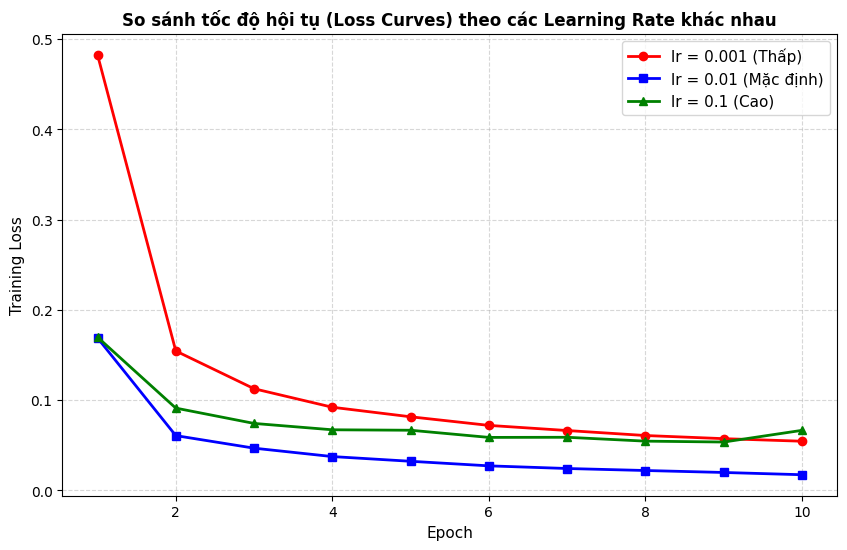

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Cấu hình thiết bị phần cứng
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

# 1. Chuẩn bị dữ liệu MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_set = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)

# 2. Kiến trúc mạng CNN gốc
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.fc1(x)

# 3. Hàm huấn luyện tổng quát trả về lịch sử loss
def train_with_lr(lr_value, num_epochs=10):
    model = MNIST_CNN().to(device)
    criterion = nn.CrossEntropyLoss()
    # Sử dụng thuật toán SGD với Momentum theo cấu hình bài Lab
    optimizer = optim.SGD(model.parameters(), lr=lr_value, momentum=0.9)

    loss_history = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        total_samples = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * images.size(0)
            total_samples += images.size(0)

        epoch_loss = running_loss / total_samples
        loss_history.append(epoch_loss)
        print(f"LR: {lr_value} | Epoch [{epoch+1}/{num_epochs}] -> Loss: {epoch_loss:.4f}")

    return loss_history

# 4. Tiến hành chạy thử nghiệm cho 3 mức Learning Rate
lr_list = [0.001, 0.01, 0.1]
results = {}

for lr in lr_list:
    print(f"\n--- ĐANG HUẤN LUYỆN VỚI LEARNING RATE = {lr} ---")
    results[lr] = train_with_lr(lr_value=lr, num_epochs=10)

# 5. Vẽ đồ thị so sánh Loss Curves giữa các Learning Rate
plt.figure(figsize=(10, 6))

# Sửa lại cú pháp dùng ngoặc vuông [...] để gọi key chính xác
plt.plot(range(1, 11), results[0.001], 'o-', color='red', linewidth=2, label='lr = 0.001 (Thấp)')
plt.plot(range(1, 11), results[0.01], 's-', color='blue', linewidth=2, label='lr = 0.01 (Mặc định)')
plt.plot(range(1, 11), results[0.1], '^-', color='green', linewidth=2, label='lr = 0.1 (Cao)')

plt.title('So sánh tốc độ hội tụ (Loss Curves) theo các Learning Rate khác nhau', fontsize=12, fontweight='bold')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('Training Loss', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()

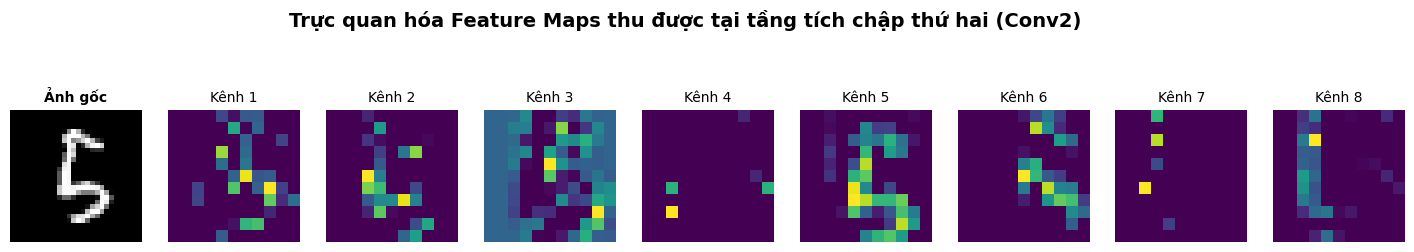

In [5]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Cấu hình thiết bị phần cứng
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Định nghĩa lại cấu trúc mạng CNN gốc (Để đảm bảo có mô hình làm việc)
class MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool  = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1   = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        return self.fc1(x)

# Khởi tạo mô hình mạng gốc
model = MNIST_CNN().to(device)
model.eval() # Chuyển sang chế độ evaluation

# 2. Lấy 1 bức ảnh mẫu ngẫu nhiên từ tập Test dữ liệu MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])
test_set = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1, shuffle=True)

# Lấy ra tensor ảnh mẫu
images, labels = next(iter(test_loader))
img_tensor = images.to(device)

# 3. Tiến hành trích xuất Feature Maps tuần tự qua các tầng
with torch.no_grad():
    # Đi qua tầng tích chập 1 + hàm kích hoạt ReLU
    fmap_conv1 = torch.relu(model.conv1(img_tensor))
    # Đi qua tầng rút gọn MaxPool 1
    fmap_pool1 = model.pool(fmap_conv1)
    # Đi qua tầng tích chập 2 + hàm kích hoạt ReLU (Đối tượng trích xuất của câu 4)
    fmap_conv2 = torch.relu(model.conv2(fmap_pool1))

# 4. Hiển thị ảnh gốc và 8 kênh Feature Maps đầu tiên của tầng Conv2
fig, axes = plt.subplots(1, 9, figsize=(18, 3))

# Ô đầu tiên vẽ ảnh gốc để đối chiếu
axes[0].imshow(images[0][0].numpy(), cmap='gray')
axes[0].axis('off')
axes[0].set_title("Ảnh gốc", fontsize=10, fontweight='bold')

# 8 ô tiếp theo vẽ các kênh đặc trưng của tầng Conv2
for i in range(8):
    # Lấy ma trận 2D của kênh thứ i tại tầng conv2
    feature_image = fmap_conv2[0, i].cpu().numpy()
    axes[i+1].imshow(feature_image, cmap='viridis')
    axes[i+1].axis('off')
    axes[i+1].set_title(f'Kênh {i+1}', fontsize=10)

plt.suptitle('Trực quan hóa Feature Maps thu được tại tầng tích chập thứ hai (Conv2)', fontsize=14, fontweight='bold', y=1.05)
plt.show()

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Cấu hình thiết bị phần cứng
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(42)

# =========================================================
# STEP 1: CẤU HÌNH DATA AUGMENTATION (TĂNG CƯỜNG DỮ LIỆU)
# =========================================================
# Bộ biến đổi cho tập TRAIN (Có thêm xoay và dịch chuyển ảnh)
train_transform_aug = transforms.Compose([
    transforms.RandomAffine(degrees=10, translate=(0.1, 0.1)), # Xoay tối đa 10 độ, dịch chuyển 10%
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Bộ biến đổi cho tập TEST (Giữ nguyên cấu trúc gốc, không biến đổi hình học)
test_transform_plain = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# Nạp dữ liệu với bộ biến đổi tương ứng
train_set_aug = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=train_transform_aug)
test_set_plain = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=test_transform_plain)

train_loader_aug = torch.utils.data.DataLoader(train_set_aug, batch_size=64, shuffle=True)
test_loader_plain = torch.utils.data.DataLoader(test_set_plain, batch_size=1000, shuffle=False)

# =========================================================
# STEP 2: ĐỊNH NGHĨA KIẾN TRÚC MẠNG TÍCH HỢP DROPOUT
# =========================================================
class Regularized_MNIST_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1   = nn.Conv2d(1, 16, kernel_size=3, stride=1, padding=0)
        self.conv2   = nn.Conv2d(16, 32, kernel_size=3, stride=1, padding=0)
        self.pool    = nn.MaxPool2d(kernel_size=2, stride=2)

        # THÊM: Lớp Dropout với tỷ lệ triệt tiêu kết nối là 25%
        self.dropout = nn.Dropout(p=0.25)

        self.fc1     = nn.Linear(32 * 5 * 5, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))
        x = self.pool(torch.relu(self.conv2(x)))

        # Áp dụng Dropout trước khi duỗi phẳng (Flatten) dữ liệu
        x = self.dropout(x)

        x = x.view(x.size(0), -1)
        return self.fc1(x)

# Khởi tạo mô hình cải tiến
model = Regularized_MNIST_CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

# =========================================================
# STEP 3: VÒNG LẶP HUẤN LUYỆN (5 EPOCH)
# =========================================================
num_epochs = 5
print("--- BẮT ĐẦU HUẤN LUYỆN MẠNG CNN CÓ DROPOUT & DATA AUGMENTATION ---")

for epoch in range(num_epochs):
    model.train() # Đảm bảo kích hoạt Dropout khi huấn luyện
    correct_train, total_train = 0, 0

    for images, labels in train_loader_aug:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        correct_train += (outputs.argmax(1) == labels).sum().item()
        total_train += images.size(0)

    # Đánh giá hiệu năng trên tập Test
    model.eval() # QUAN TRỌNG: Tự động tắt tính năng Dropout khi dự đoán mẫu test
    correct_test, total_test = 0, 0
    with torch.no_grad():
        for images, labels in test_loader_plain:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            correct_test += (outputs.argmax(1) == labels).sum().item()
            total_test += images.size(0)

    print(f"Epoch [{epoch+1}/{num_epochs}] -> Train Acc: {correct_train/total_train*100:.2f}% | Test Acc: {correct_test/total_test*100:.2f}%")

--- BẮT ĐẦU HUẤN LUYỆN MẠNG CNN CÓ DROPOUT & DATA AUGMENTATION ---
Epoch [1/5] -> Train Acc: 86.20% | Test Acc: 98.05%
Epoch [2/5] -> Train Acc: 93.95% | Test Acc: 98.29%
Epoch [3/5] -> Train Acc: 95.19% | Test Acc: 98.67%
Epoch [4/5] -> Train Acc: 95.62% | Test Acc: 98.73%
Epoch [5/5] -> Train Acc: 96.07% | Test Acc: 98.77%
